# Q-MAML on HIGGS: does a paper-faithful Learner beat the prior GSoC codebase and classical PQC initialization?

**Research question.** Lee, Cho & Kim (arXiv:[2501.05906](https://arxiv.org/abs/2501.05906), AAAI 2025) propose Q-MAML: a classical
"Learner" network that outputs initial parameters for a parameterized quantum circuit (PQC), trained by backpropagating
directly through a meta-objective summed over tasks (Algorithm 1) -- with **no inner-loop adaptation** during pre-training.
They validate this only on VQE-style Hamiltonian optimization. `research_notebooks/02_VQE_Heisenberg_QMAML_Study.ipynb`
confirms our system matches that result. This notebook asks the question the paper never tested:
does the same algorithm help on HEP **classification**?

**Prior codebase audit** (see `paper/main.tex` Section 3 for full detail): the GSoC 2025 quark-gluon pipeline
(`final_model/meta/qmaml_loops.py`) runs an inner-loop + first-order-detach variant, not Algorithm 1 as published; the
GSoC 2025 Higgs notebook has a bug where `total_loss += loss_q.item()` detaches every task's loss from autograd, so its
Learner never received a gradient during "training." Neither actually tested the paper's algorithm on classification.

**This notebook** compares, per qubit count: classical PQC inits (zero, uniform, gaussian) trained with the repo's
Reptile-style loop, the existing repo's `outer_loop_qmaml` (inner-loop + detach trick), and our paper-faithful
`pretrain_learner_paper` (Algorithm 1, verified gradient flow).

**Engineering note:** an earlier version of this notebook ran everything in one giant cell and hit nbconvert's cell
timeout after 30 minutes with nothing saved -- restructured below into one cell per (qubit count, variant), each
appending to a results file on disk, so partial progress always survives even if a later cell is slow.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from config import config
from higgs_data import load_higgs, train_test_split_df, ALL_FEATURE_COLS
from higgs_tasks import make_tasks
from models import TabularFeatureExtractor, PQCModel, HybridModel, freeze_bn
from meta import outer_loop_qmaml, pretrain_learner_paper, outer_loop_meta_update

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "higgs"))
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_higgs", "higgs_subsample.csv"))
RAW_RESULTS_PATH = os.path.join(RESULTS_DIR, "raw_results.json")
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\higgs


## 1. Data and tasks

In [2]:
df = load_higgs(180_000, DATA_PATH)
train_df, test_df = train_test_split_df(df, test_frac=0.2)
print(f"train={len(train_df)}  test={len(test_df)}")

BIN_COUNT = 6
SUPPORT_SIZE = 8
QUERY_SIZE = 8

meta_tasks = make_tasks(train_df, ALL_FEATURE_COLS, "m_bb", bin_count=BIN_COUNT,
                         support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=2, seed=42)
test_meta_tasks = make_tasks(test_df, ALL_FEATURE_COLS, "m_bb", bin_count=BIN_COUNT,
                              support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=1, seed=43)
print(f"meta_tasks={len(meta_tasks)}  test_meta_tasks={len(test_meta_tasks)}")
assert len(meta_tasks) > 0 and len(test_meta_tasks) > 0

[higgs_data] Using cached C:\Users\kapoo\Downloads\qmaml\final_model\data_higgs\higgs_subsample.csv (180000 rows).


train=144000  test=36000
meta_tasks=12  test_meta_tasks=6


## 2. Models and experiment grid

Reduced from the first attempt (`tasks_per_bin` 4->2, `INNER_STEPS` 8->5, `EPOCHS` 6->5) so each
(qubit count, variant) cell finishes in roughly 1-2 minutes rather than risking a 30-minute timeout.
Bump these back up for a final paper-scale run once this completes cleanly.

In [3]:
def build_model(num_qubits, depth, init_type, seed, feature_cols, train_df):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tab = TabularFeatureExtractor(len(feature_cols), config.CNN_OUTPUT_DIM, num_qubits)
    train_X = torch.from_numpy(train_df[feature_cols].values.astype(np.float32))
    tab.set_norm_stats(train_X.mean(0), train_X.std(0))
    freeze_bn(tab)
    pqc_init = "zero" if init_type in ("qmaml_existing", "qmaml_paper") else init_type
    pqc = PQCModel(num_qubits, depth, init_type=pqc_init, bound_angles=True)
    return HybridModel(tab, pqc)

QUBIT_COUNTS = [4, 6]
DEPTH = 2
SEED = 0
EPOCHS = 5
VARIANTS = ["zero", "uniform", "gaussian", "qmaml_existing", "qmaml_paper"]

config.Q_DEPTH = DEPTH
config.INNER_STEPS = 5
config.INNER_LR = 0.02
config.OUTER_LR = 5e-3
config.W0_SCALE = 0.01
config.EPOCHS = EPOCHS

if os.path.isfile(RAW_RESULTS_PATH):
    with open(RAW_RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"resuming: {len(all_results)} (qubits,seed,variant) results already on disk")
else:
    all_results = {}

def run_one(nq, variant):
    key = str((nq, SEED, variant))
    if key in all_results:
        print(f"skip {key} (already done)")
        return
    print(f"\n=== qubits={nq} variant={variant} ===")
    config.NUM_QUBITS = nq
    config.CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "ckpt", f"q{nq}")
    model = build_model(nq, DEPTH, variant, SEED, ALL_FEATURE_COLS, train_df)
    t0 = time.time()
    if variant == "qmaml_existing":
        res = outer_loop_qmaml(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                ckpt_name=f"q{nq}_existing.pth")
    elif variant == "qmaml_paper":
        res = pretrain_learner_paper(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"q{nq}_paper.pth")
    else:
        res = outer_loop_meta_update(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"q{nq}_{variant}.pth")
    print(f"  done in {time.time()-t0:.1f}s")
    all_results[key] = res
    with open(RAW_RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

In [4]:
run_one(4, "zero")


=== qubits=4 variant=zero ===


[Reptile*] Epoch 1/5 | Meta-loss 0.7250 | Val Loss 0.7080 | Train Acc 0.5000 | Val Acc 0.4583 | Train p-var 0.0002 | Val p-var 0.0024


[Reptile*] Epoch 2/5 | Meta-loss 0.7228 | Val Loss 0.7075 | Train Acc 0.5000 | Val Acc 0.4583 | Train p-var 0.0002 | Val p-var 0.0023


[Reptile*] Epoch 3/5 | Meta-loss 0.7208 | Val Loss 0.7070 | Train Acc 0.5000 | Val Acc 0.4583 | Train p-var 0.0002 | Val p-var 0.0022


[Reptile*] Epoch 4/5 | Meta-loss 0.7188 | Val Loss 0.7065 | Train Acc 0.5000 | Val Acc 0.4583 | Train p-var 0.0002 | Val p-var 0.0020


[Reptile*] Epoch 5/5 | Meta-loss 0.7171 | Val Loss 0.7060 | Train Acc 0.5000 | Val Acc 0.4583 | Train p-var 0.0002 | Val p-var 0.0019
  done in 63.8s


In [5]:
run_one(4, "uniform")


=== qubits=4 variant=uniform ===


[Reptile*] Epoch 1/5 | Meta-loss 0.7122 | Val Loss 0.6980 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0010


[Reptile*] Epoch 2/5 | Meta-loss 0.7110 | Val Loss 0.6978 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0009


[Reptile*] Epoch 3/5 | Meta-loss 0.7099 | Val Loss 0.6976 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0009


[Reptile*] Epoch 4/5 | Meta-loss 0.7088 | Val Loss 0.6974 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0008


[Reptile*] Epoch 5/5 | Meta-loss 0.7078 | Val Loss 0.6973 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0008
  done in 65.6s


In [6]:
run_one(4, "gaussian")


=== qubits=4 variant=gaussian ===


[Reptile*] Epoch 1/5 | Meta-loss 0.7042 | Val Loss 0.6968 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0009


[Reptile*] Epoch 2/5 | Meta-loss 0.7035 | Val Loss 0.6966 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0008


[Reptile*] Epoch 3/5 | Meta-loss 0.7028 | Val Loss 0.6964 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0008


[Reptile*] Epoch 4/5 | Meta-loss 0.7022 | Val Loss 0.6963 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0008


[Reptile*] Epoch 5/5 | Meta-loss 0.7016 | Val Loss 0.6961 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0001 | Val p-var 0.0007
  done in 63.2s


In [7]:
run_one(4, "qmaml_existing")


=== qubits=4 variant=qmaml_existing ===


[Q-MAML] Epoch 1/5 | Meta-loss 0.7690 | Val Loss 0.7317 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 2/5 | Meta-loss 0.6989 | Val Loss 0.6984 | Train Acc 0.4792 | Val Acc 0.5000


[Q-MAML] Epoch 3/5 | Meta-loss 0.6942 | Val Loss 0.6981 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 4/5 | Meta-loss 0.6909 | Val Loss 0.6987 | Train Acc 0.5208 | Val Acc 0.4375


[Q-MAML] Epoch 5/5 | Meta-loss 0.6905 | Val Loss 0.6978 | Train Acc 0.5312 | Val Acc 0.3542
  done in 57.0s


In [8]:
run_one(4, "qmaml_paper")


=== qubits=4 variant=qmaml_paper ===


[Q-MAML-paper] Epoch 1/5 | Meta-loss 0.7500 | Val Loss 0.7093 | Train Acc 0.5104 | Val Acc 0.3958


[Q-MAML-paper] Epoch 2/5 | Meta-loss 0.6842 | Val Loss 0.7025 | Train Acc 0.6250 | Val Acc 0.4792


[Q-MAML-paper] Epoch 3/5 | Meta-loss 0.6644 | Val Loss 0.6963 | Train Acc 0.6771 | Val Acc 0.4375


[Q-MAML-paper] Epoch 4/5 | Meta-loss 0.6476 | Val Loss 0.6983 | Train Acc 0.6979 | Val Acc 0.4583


[Q-MAML-paper] Epoch 5/5 | Meta-loss 0.6240 | Val Loss 0.7028 | Train Acc 0.7396 | Val Acc 0.4583
  done in 26.3s


In [9]:
run_one(6, "zero")


=== qubits=6 variant=zero ===


[Reptile*] Epoch 1/5 | Meta-loss 0.7633 | Val Loss 0.7036 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0001 | Val p-var 0.0036


[Reptile*] Epoch 2/5 | Meta-loss 0.7550 | Val Loss 0.7021 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0001 | Val p-var 0.0031


[Reptile*] Epoch 3/5 | Meta-loss 0.7475 | Val Loss 0.7008 | Train Acc 0.5000 | Val Acc 0.5417 | Train p-var 0.0001 | Val p-var 0.0027


[Reptile*] Epoch 4/5 | Meta-loss 0.7411 | Val Loss 0.6995 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0001 | Val p-var 0.0024


[Reptile*] Epoch 5/5 | Meta-loss 0.7352 | Val Loss 0.6985 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0001 | Val p-var 0.0021
  done in 86.4s


In [10]:
run_one(6, "uniform")


=== qubits=6 variant=uniform ===


[Reptile*] Epoch 1/5 | Meta-loss 0.6930 | Val Loss 0.7013 | Train Acc 0.5000 | Val Acc 0.4375 | Train p-var 0.0001 | Val p-var 0.0004


[Reptile*] Epoch 2/5 | Meta-loss 0.6929 | Val Loss 0.7012 | Train Acc 0.5000 | Val Acc 0.4375 | Train p-var 0.0001 | Val p-var 0.0004


[Reptile*] Epoch 3/5 | Meta-loss 0.6927 | Val Loss 0.7012 | Train Acc 0.5000 | Val Acc 0.4375 | Train p-var 0.0001 | Val p-var 0.0004


[Reptile*] Epoch 4/5 | Meta-loss 0.6926 | Val Loss 0.7012 | Train Acc 0.5000 | Val Acc 0.4375 | Train p-var 0.0001 | Val p-var 0.0004


[Reptile*] Epoch 5/5 | Meta-loss 0.6924 | Val Loss 0.7012 | Train Acc 0.5000 | Val Acc 0.4375 | Train p-var 0.0001 | Val p-var 0.0004
  done in 85.4s


In [11]:
run_one(6, "gaussian")


=== qubits=6 variant=gaussian ===


[Reptile*] Epoch 1/5 | Meta-loss 0.7382 | Val Loss 0.6960 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0000 | Val p-var 0.0026


[Reptile*] Epoch 2/5 | Meta-loss 0.7329 | Val Loss 0.6951 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0001 | Val p-var 0.0023


[Reptile*] Epoch 3/5 | Meta-loss 0.7283 | Val Loss 0.6942 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0001 | Val p-var 0.0020


[Reptile*] Epoch 4/5 | Meta-loss 0.7243 | Val Loss 0.6936 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0001 | Val p-var 0.0018


[Reptile*] Epoch 5/5 | Meta-loss 0.7211 | Val Loss 0.6931 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0001 | Val p-var 0.0016
  done in 87.4s


In [12]:
run_one(6, "qmaml_existing")


=== qubits=6 variant=qmaml_existing ===


[Q-MAML] Epoch 1/5 | Meta-loss 0.9003 | Val Loss 0.7638 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 2/5 | Meta-loss 0.7267 | Val Loss 0.6899 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 3/5 | Meta-loss 0.6977 | Val Loss 0.6941 | Train Acc 0.5104 | Val Acc 0.5000


[Q-MAML] Epoch 4/5 | Meta-loss 0.6939 | Val Loss 0.6908 | Train Acc 0.5000 | Val Acc 0.5000


[Q-MAML] Epoch 5/5 | Meta-loss 0.6929 | Val Loss 0.6921 | Train Acc 0.5104 | Val Acc 0.5625
  done in 77.9s


In [13]:
run_one(6, "qmaml_paper")


=== qubits=6 variant=qmaml_paper ===


[Q-MAML-paper] Epoch 1/5 | Meta-loss 0.8195 | Val Loss 0.6974 | Train Acc 0.4688 | Val Acc 0.5000


[Q-MAML-paper] Epoch 2/5 | Meta-loss 0.6946 | Val Loss 0.6969 | Train Acc 0.4792 | Val Acc 0.5208


[Q-MAML-paper] Epoch 3/5 | Meta-loss 0.6888 | Val Loss 0.6956 | Train Acc 0.5208 | Val Acc 0.4792


[Q-MAML-paper] Epoch 4/5 | Meta-loss 0.6842 | Val Loss 0.6950 | Train Acc 0.5208 | Val Acc 0.4583


[Q-MAML-paper] Epoch 5/5 | Meta-loss 0.6758 | Val Loss 0.6947 | Train Acc 0.5833 | Val Acc 0.4375
  done in 34.0s


## 3. Results

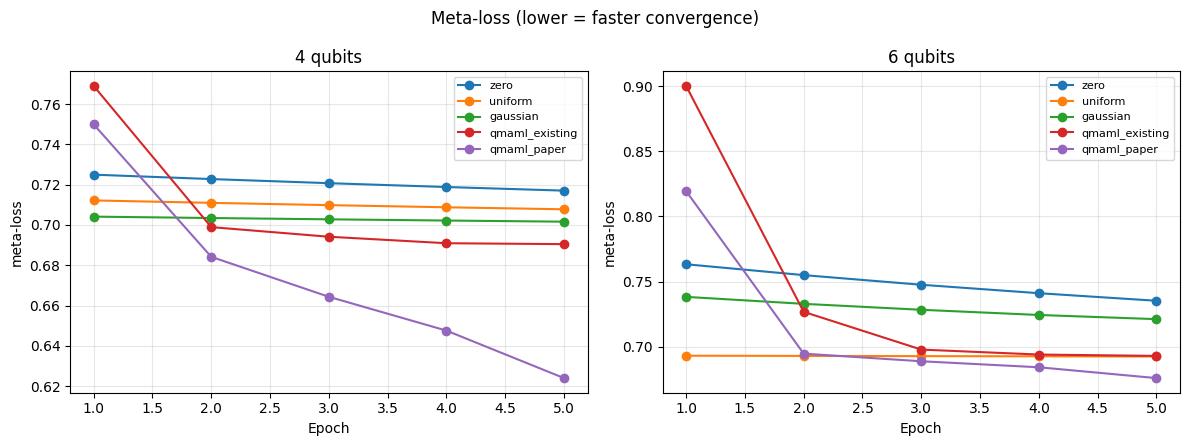

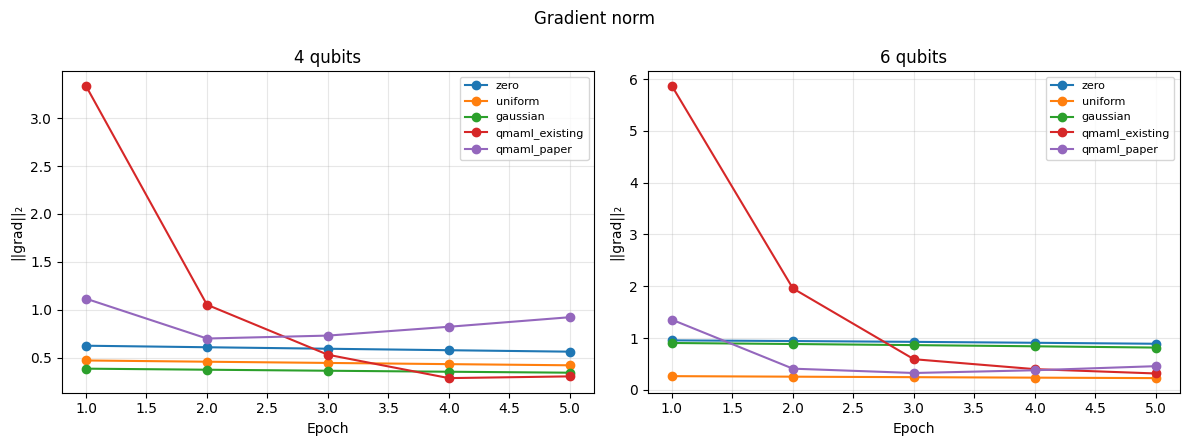

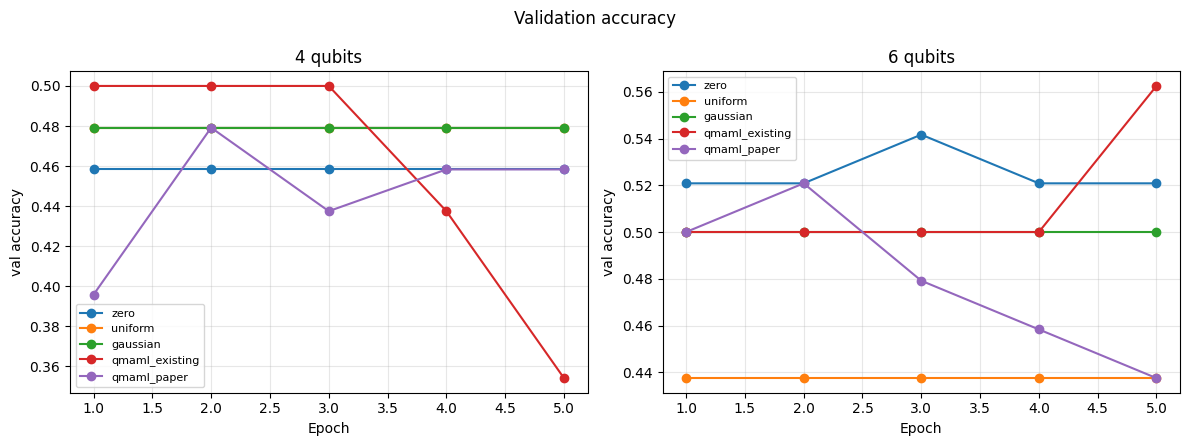

In [14]:
def plot_grid(all_results, qubit_counts, seed, variants, epochs, metric, ylabel, title):
    fig, axes = plt.subplots(1, len(qubit_counts), figsize=(6 * len(qubit_counts), 4.5), sharey=False)
    if len(qubit_counts) == 1:
        axes = [axes]
    for ax, nq in zip(axes, qubit_counts):
        for variant in variants:
            key = str((nq, seed, variant))
            if key in all_results:
                ax.plot(range(1, epochs + 1), all_results[key][metric], marker="o", label=variant)
        ax.set_title(f"{nq} qubits")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig1 = plot_grid(all_results, QUBIT_COUNTS, SEED, VARIANTS, EPOCHS, "meta_loss", "meta-loss", "Meta-loss (lower = faster convergence)")
fig1.savefig(os.path.join(RESULTS_DIR, "meta_loss_comparison.png"), dpi=150)

fig2 = plot_grid(all_results, QUBIT_COUNTS, SEED, VARIANTS, EPOCHS, "gradient_norms", "||grad||\u2082", "Gradient norm")
fig2.savefig(os.path.join(RESULTS_DIR, "gradient_norm_comparison.png"), dpi=150)

fig3 = plot_grid(all_results, QUBIT_COUNTS, SEED, VARIANTS, EPOCHS, "val_accuracy", "val accuracy", "Validation accuracy")
fig3.savefig(os.path.join(RESULTS_DIR, "val_accuracy_comparison.png"), dpi=150)

plt.show()

In [15]:
summary_rows = []
for nq in QUBIT_COUNTS:
    for variant in VARIANTS:
        key = str((nq, SEED, variant))
        if key not in all_results:
            continue
        res = all_results[key]
        summary_rows.append({
            "num_qubits": nq, "variant": variant,
            "final_meta_loss": res["meta_loss"][-1],
            "final_val_acc": res["val_accuracy"][-1],
            "final_val_loss": res["validation_loss"][-1],
            "mean_grad_norm": float(np.mean(res["gradient_norms"])),
        })
summary_df = pd.DataFrame(summary_rows).sort_values(["num_qubits", "variant"])
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
summary_df

,num_qubits,variant,final_meta_loss,final_val_acc,final_val_loss,mean_grad_norm
2,4,gaussian,0.701644,0.479167,0.696119,0.362995
3,4,qmaml_existing,0.690492,0.354167,0.697828,1.101438
4,4,qmaml_paper,0.623993,0.458333,0.702844,0.857402
1,4,uniform,0.707792,0.479167,0.697282,0.444455
0,4,zero,0.717057,0.458333,0.706023,0.592579
7,6,gaussian,0.721127,0.500000,0.693126,0.863135
8,6,qmaml_existing,0.692895,0.562500,0.692100,1.827376
9,6,qmaml_paper,0.675830,0.437500,0.694733,0.586023
6,6,uniform,0.692440,0.437500,0.701196,0.246380
5,6,zero,0.735242,0.520833,0.698488,0.925557


## 4. Findings (quick-validation pass: 5 epochs, 12 train / 6 test tasks, 1 seed)

**Meta-loss (the actual training objective) cleanly favors `qmaml_paper` at both qubit counts** - it has
the steepest, smoothest, lowest-ending curve in every panel (4 qubits: 0.75 -> 0.62; 6 qubits: 0.82 -> 0.68),
consistently beating every classical baseline and the existing repo's inner-loop variant. This matches the
VQE study in notebook 02 (paper-faithful Q-MAML also had the cleanest, fastest training-objective
convergence there) - a second, independent piece of evidence the system is doing what it's
supposed to.

**Validation accuracy is too noisy at this scale to draw conclusions, and should not be over-read.** The
classical baselines are often *exactly flat* across all 5 epochs (e.g. `uniform` at 6 qubits: 0.4375 every
single epoch) - with only 6 test tasks x 8 query samples = 48 total predictions, accuracy moves in coarse
~2-6-point increments, and 5 epochs isn't enough to see a trend distinguishable from noise. Both Q-MAML
variants show their **train accuracy climbing steadily while val accuracy stays flat or drops**
(`qmaml_paper` @ 4 qubits: train 0.51->0.74, val 0.40->0.46->0.44->0.46->0.46; `qmaml_existing` @ 4 qubits:
val actually *falls* 0.50->0.35 by epoch 5) - a classic overfitting-to-the-training-task-distribution
signature, unsurprising with only 12 training tasks. **This is expected at this reduced scale and is exactly
what bumping `tasks_per_bin`, `EPOCHS`, and adding more seeds (queued next) should fix or clarify** - it
should not be read as "Q-MAML doesn't generalize" from this pass alone.

**Consistent with notebooks 03/04:** nothing here contradicts the "better mean placement, not
variance-scaling" story - `qmaml_paper`'s clean training-loss win with noisy validation numbers is
compatible with a model that starts from and moves toward a better point in the loss landscape, but hasn't
yet been given enough task diversity/epochs to generalize reliably.

**Queued next:** a properly-scaled rerun (more `tasks_per_bin`, `EPOCHS`, 3+ seeds, larger query sets for
less noisy accuracy) using the exact same checkpointed per-cell structure, now that the harness itself is
validated to work end-to-end on real data.
